<a href="https://colab.research.google.com/github/amrzhd/EEGNet/blob/main/EEGNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Motor Imagery Task Classification


#Extracting Data

##Downloading BCI Competition IV 2a Dataset

In [68]:
#!wget https://www.bbci.de/competition/download/competition_iv/BCICIV_2a_gdf.zip

In [69]:
#!mkdir -p /content/cleaned_data/

In [70]:
%%capture
#!unzip /content/BCICIV_2a_gdf.zip -d raw_data

#Installing Packages

In [71]:
%%capture
#!pip install mne

In [72]:
%%capture
#!pip install torch-summary

#Libraries Used

In [73]:
import os
import mne
import math
import copy
import gdown
import random
import scipy.io
import numpy as np
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt

# Torch
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchsummary import summary
from torch.autograd import Variable
from torch.utils.data import DataLoader, TensorDataset, random_split

# Scikit-Learn
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split

# Building Dataset

In [74]:
!mkdir -p /content/cleaned_data/first_session
!mkdir -p /content/cleaned_data/second_session

�����﷨����ȷ��
�����﷨����ȷ��


##First Session

In [75]:
# 导入必要的库
import os
import mne

# 设置原始数据和处理后数据的文件夹路径
raw_data_folder = 'D:\\Python Program\\EEGNet-main\\content\\raw_data'  # 原始GDF文件存放路径
cleaned_data_folder = 'D:\\Python Program\\EEGNet-main\\content\\cleaned_data\\first_session'  # 处理后的FIF文件存放路径

# 获取原始数据文件夹中的所有文件名
files = os.listdir(raw_data_folder)

# 从文件列表中筛选出以'T.gdf'结尾的文件（通常T表示训练数据）
filtered_files = [file for file in files if file.endswith('T.gdf')]

# 初始化一个空列表，用于存储处理后的raw对象
raw_list = []

# 遍历筛选出的文件，对每个文件进行预处理
for file in filtered_files:
    # 构建完整的文件路径
    file_path = os.path.join(raw_data_folder, file)
    
    # 读取原始GDF格式的脑电数据
    # eog参数指定EOG通道名称，preload=True表示将数据加载到内存
    raw = mne.io.read_raw_gdf(file_path, eog=['EOG-left', 'OG-central', 'EOG-right'], preload=True)
    
    # 删除EOG（眼电）通道，只保留EEG通道
    raw.drop_channels(['EOG-left', 'EOG-central', 'EOG-right'])
    
    # 应用4-40Hz的带通滤波器，去除低频和高频噪声
    # 4Hz以上可去除直流偏移和慢波，40Hz以下可去除高频肌电等噪声
    raw.filter(l_freq=4, h_freq=40, method='iir')
    
    # 应用50Hz陷波滤波器，去除电源线干扰
    raw.notch_filter(freqs=50)
    
    # 构建保存路径，将文件扩展名从.gdf改为.fif
    new_file_path = os.path.join(cleaned_data_folder, file[:-4] + '.fif')
    
    # 将处理后的数据保存为FIF格式文件
    raw.save(new_file_path, overwrite=True)
    
    # 将处理后的raw对象添加到列表中
    raw_list.append(raw)

# 将所有处理后的raw对象在时间维度上合并成一个raw对象
final_raw = mne.concatenate_raws(raw_list)

# 构建合并后文件的保存路径
new_file_path = os.path.join(cleaned_data_folder, 'First_Session_Subjects.fif')

# 保存合并后的数据到单个FIF文件
final_raw.save(new_file_path, overwrite=True)

# 输出处理完成的信息
print(f"数据处理完成！共处理了{len(filtered_files)}个文件。")
print(f"单个处理文件保存在：{cleaned_data_folder}")
print(f"合并文件保存在：{new_file_path}")

Extracting GDF parameters from D:\Python Program\EEGNet-main\content\raw_data\A01T.gdf...
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG, EOG-central
Creating raw.info structure...
Reading 0 ... 672527  =      0.000 ...  2690.108 secs...


c:\Users\Winson\anaconda3\envs\mne\Lib\contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 4 - 40 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 4.00, 40.00 Hz: -6.02, -6.02 dB

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge: 50.62 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 50.88 Hz)
- Filter length: 1651 samples (6.604 s)

Overwriting existing file.
Writing D:\Python Program\EEGNet-main\content\cleaned_data\first_session\A01T.fif
Overwriting ex

C:\Users\Winson\AppData\Local\Temp\ipykernel_30704\4087429198.py:41: RuntimeWarning: This filename (D:\Python Program\EEGNet-main\content\cleaned_data\first_session\A01T.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw.save(new_file_path, overwrite=True)


Closing D:\Python Program\EEGNet-main\content\cleaned_data\first_session\A01T.fif
[done]
Extracting GDF parameters from D:\Python Program\EEGNet-main\content\raw_data\A02T.gdf...
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG, EOG-central
Creating raw.info structure...
Reading 0 ... 677168  =      0.000 ...  2708.672 secs...


...

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 4 - 40 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 4.00, 40.00 Hz: -6.02, -6.02 dB

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge: 50.62 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 50.88 Hz)
- Filter length: 1651 samples (6.604 s)

Overwriting existing file.
Writing D:\Python Program\EEGNet-main\content\cleaned_data\first_session\A09T.fif
Overwriting ex

C:\Users\Winson\AppData\Local\Temp\ipykernel_30704\4087429198.py:41: RuntimeWarning: This filename (D:\Python Program\EEGNet-main\content\cleaned_data\first_session\A09T.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw.save(new_file_path, overwrite=True)


Closing D:\Python Program\EEGNet-main\content\cleaned_data\first_session\A09T.fif
[done]
Overwriting existing file.
Writing D:\Python Program\EEGNet-main\content\cleaned_data\first_session\First_Session_Subjects.fif
Overwriting existing file.


C:\Users\Winson\AppData\Local\Temp\ipykernel_30704\4087429198.py:53: RuntimeWarning: This filename (D:\Python Program\EEGNet-main\content\cleaned_data\first_session\First_Session_Subjects.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  final_raw.save(new_file_path, overwrite=True)


Closing D:\Python Program\EEGNet-main\content\cleaned_data\first_session\First_Session_Subjects.fif
[done]
数据处理完成！共处理了9个文件。
单个处理文件保存在：D:\Python Program\EEGNet-main\content\cleaned_data\first_session
合并文件保存在：D:\Python Program\EEGNet-main\content\cleaned_data\first_session\First_Session_Subjects.fif


事件列表​  
'1023': 1 拒绝的试验  
'1072': 2 眼动  
'276': 3 静息态脑电图（睁眼）  
'277': 4 静息态脑电图（闭眼）  
'32766': 5 新一组开始  
'768': 6 试验开始  
'769': 7 提示开始 左手（类别1）：0  
'770': 8 提示开始 右手（类别2）：1  
'771': 9 提示开始 脚（类别3）：2    
'772': 10 提示开始 舌头（类别4）：3 

In [76]:
events = mne.events_from_annotations(final_raw)
events[1]

Used Annotations descriptions: [np.str_('1023'), np.str_('1072'), np.str_('276'), np.str_('277'), np.str_('32766'), np.str_('768'), np.str_('769'), np.str_('770'), np.str_('771'), np.str_('772')]


{np.str_('1023'): 1,
 np.str_('1072'): 2,
 np.str_('276'): 3,
 np.str_('277'): 4,
 np.str_('32766'): 5,
 np.str_('768'): 6,
 np.str_('769'): 7,
 np.str_('770'): 8,
 np.str_('771'): 9,
 np.str_('772'): 10}

时间窗选择：​   
[0秒, 4秒] 提示开始后：[2秒, 6秒]

In [77]:
# 从原始 EEG 数据中创建 Epochs（试次）对象
# 参数说明：
#   final_raw          - 之前合并所有被试的原始 Raw 对象（已滤波）
#   events[0]          - mne.events_from_annotations() 返回的事件矩阵，
#                         形状 (N, 3)，每行 [起始采样点, 保留字段, 事件ID]
#                         第一列即事件发生的采样点位置
#   event_id=[7,8]     - 只提取两种运动想象事件：
#                          7  → 769 → 左手运动想象 (cue onset left)
#                          8  → 770 → 右手运动想象 (cue onset right)
#   tmin=0, tmax=4      - 以事件发生时刻为 0 点，截取 0~4 秒的时间窗
#                         （对应 cue 出现后 0~4 秒，即完整运动想象期）
#   reject=None         - 不拒绝任何试次（即使某些试次幅值异常也保留）
#   baseline=None       - 不做基线校正（不以刺激前基线做归一化）
#   preload=True        - 立即将数据加载到内存，后续 get_data() 更快
epochs = mne.Epochs(final_raw, events[0], event_id=[7, 8], tmin=0, tmax=4, reject=None, baseline=None, preload=True)

# 提取 Epochs 数据为 numpy 数组
# 形状: (n_epochs, n_channels, n_times)
#   第一维：试次数量（1296 = 9 被试 × 6 runs × 12 trials × 2 类）
#   第二维：通道数量（22）
#   第三维：时间采样点数（250Hz × 4s = 1000 点 + 1 = 1001）
# copy=True：返回副本而非视图，避免后续修改影响原始 epoch 对象
first_session_data = epochs.get_data(copy=True)

# 提取每个试次对应的类别标签
# epochs.events 形状: (n_epochs, 3)
#   第 0 列：事件采样点位置
#   第 1 列：保留字段（通常为 0）
#   第 2 列：事件 ID（7=左, 8=右）
# [:, -1] 取最后一列即事件 ID
first_session_labels = epochs.events[:,-1]

Not setting metadata
1296 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 1296 events and 1001 original time points ...
0 bad epochs dropped


In [78]:
print("First_session_dataset shape:",first_session_data.shape)

First_session_dataset shape: (1296, 22, 1001)


##Second Session

###Extracting Labels for datas with "E.gdf" prefix

In [79]:
# Replace this with your actual shareable link
# shareable_link = 'https://drive.google.com/file/d/11Ke2Xta1kv2xu2Mybuu_X51zJYjQ-VFo/view?usp=drive_link'

# Extract file ID from the shareable link
# file_id = shareable_link.split('/d/')[1].split('/view')[0]

# Create the direct download link
# download_url = f'https://drive.google.com/uc?id={file_id}&export=download'

# Specify the output file path
# output_file = 'true_labels.zip'

# Download the file
# gdown.download(download_url, output_file, quiet=False)

In [80]:
%%capture
# !unzip /content/true_labels.zip -d second_session_labels

###Extracting datas of second session

In [81]:
# =============================================================================
# Second Session 数据处理 —— 从 GDF 文件加载 EEG 并匹配 .mat 标签文件
# =============================================================================

# 路径配置（本地 Windows 环境）
raw_data_folder = 'D:\\Python Program\\EEGNet-main\\content\\raw_data'                     # 原始 GDF 文件目录
cleaned_data_folder = 'D:\\Python Program\\EEGNet-main\\content\\cleaned_data\\second_session\\'  # 处理后数据输出目录
mat_folder = 'D:\\Python Program\\EEGNet-main\\content\\second_session_labels\\'            # 标签 .mat 文件目录

# -----------------------------------------------------------------------------
# 第一步：获取标签文件列表（仅用于后续匹配，实际读取在循环内进行）
# -----------------------------------------------------------------------------
mat_files = os.listdir(mat_folder)                                          # 列出标签目录下所有文件
filtered_math_labels = [file for file in mat_files if file.endswith('E.mat')]  # 只保留以 'E.mat' 结尾的标签文件
# 注：filtered_math_labels 变量定义后在后续代码中并未被使用，
#     实际标签匹配在循环内通过 file.replace('.gdf', '.mat') 动态拼接文件名完成

# -----------------------------------------------------------------------------
# 第二步：获取 GDF 数据文件列表
# -----------------------------------------------------------------------------
files = os.listdir(raw_data_folder)                                        # 列出原始数据目录下所有文件
filtered_files = [file for file in files if file.endswith('E.gdf')]         # 只保留以 'E.gdf' 结尾的 Second Session 文件
# 文件命名格式：A01E.gdf, A02E.gdf, ..., A09E.gdf（9 个被试的评估阶段数据）

# -----------------------------------------------------------------------------
# 第三步：逐文件处理（加载 → 滤波 → 存 .fif → 匹配标签）
# -----------------------------------------------------------------------------
raw_list = []                          # 用于存储每个被试的 Raw 对象，最后拼接
second_session_labels = np.array([])   # 初始化空的标签数组，逐被试追加

for file in filtered_files:
    file_path = os.path.join(raw_data_folder, file)

    # --- 3.1 读取原始 GDF 文件 ---
    # eog=['EOG-left','EOG-central','EOG-right']：
    #   将这三个通道专门标记为 EOG 类型，便于后续处理（如 ICA 去伪迹）
    # preload=True：立即将数据读入内存
    raw = mne.io.read_raw_gdf(file_path, eog=['EOG-left', 'EOG-central', 'EOG-right'], preload=True)

    # --- 3.2 丢弃 EOG 通道 ---
    # 注：根据 BCI Competition IV 2a 官方说明，EOG 通道仅用于伪迹处理，不得用于分类
    #     但此处是直接丢弃而非使用 ICA 去除 EEG 中的眼电成分，
    #     参考预处理架构建议在丢弃 EOG 前先做 ICA 去伪迹 [3]
    raw.drop_channels(['EOG-left', 'EOG-central', 'EOG-right'])

    # --- 3.3 带通滤波 4-40 Hz ---
    # method='iir'：使用 IIR 滤波器（Butterworth 带通，零相位双向滤波）
    # 4-40 Hz 覆盖 mu 节律 (8-13 Hz) 和 beta 节律 (13-30 Hz)，同时去除低频漂移和高频肌电噪声
    # 注：参考预处理架构建议滤波顺序为 Notch → High-Pass → Low-Pass（具因果性）[3]，
    #     但此处未做 50 Hz 陷波（Notch），因数据集在记录时已启用 50 Hz 陷波滤波器
    raw.filter(l_freq=4, h_freq=40, method='iir')

    # --- 3.4 保存处理后的数据为 .fif 格式 ---
    # file[:-4]：去掉 '.gdf' 后缀，如 'A01E.gdf' → 'A01E'
    # 保存为 MNE 原生 .fif 格式，便于后续快速加载
    new_file_path = os.path.join(cleaned_data_folder, file[:-4] + '.fif')
    raw.save(new_file_path, overwrite=True)

    # 将处理后的 Raw 对象加入列表
    raw_list.append(raw)

    # --- 3.5 加载对应的 .mat 标签文件 ---
    # 文件名拼接：将 '.gdf' 替换为 '.mat'
    # 例：'A01E.gdf' → 'A01E.mat'
    mat_file_name = file.replace('.gdf', '.mat')
    mat_file_path = os.path.join(mat_folder, mat_file_name)
    print(f"data:{file}, label:{mat_file_name}")  # 打印当前处理的文件对

    # 检查对应的 .mat 标签文件是否存在
    if os.path.exists(mat_file_path):
        # 使用 scipy 加载 MATLAB 格式的 .mat 文件
        mat_data = scipy.io.loadmat(mat_file_path)

        # 提取 'classlabel' 字段 —— 包含每个 trial 的类别编号
        # 类别标签：1=左手, 2=右手, 3=脚, 4=舌头
        class_labels = mat_data.get('classlabel', [])  # 若字段不存在则返回空列表

        # 检查 'classlabel' 是否存在且非空
        if class_labels.size > 0:
            # 转换为 1D numpy int 数组
            # .flatten() 确保是一维向量（.mat 文件中可能是列向量）
            class_labels_array = np.array(class_labels, dtype=int).flatten()

            # 追加到总标签数组中
            # np.concatenate 在每次循环中复制整个数组，
            # 对 9 个被试规模性能影响不大，但大规模数据建议先收集到 list 再一次性拼接
            second_session_labels = np.concatenate((second_session_labels, class_labels_array))
        else:
            print(f"Warning: 'classlabel' not found or empty in {mat_file_name}.")
    else:
        print(f"Warning: {mat_file_name} not found.")

# -----------------------------------------------------------------------------
# 第四步：合并所有被试数据并保存
# -----------------------------------------------------------------------------
# mne.concatenate_raws 将所有被试的 Raw 对象沿时间轴拼接为一个连续 Raw 对象
final_raw = mne.concatenate_raws(raw_list)

# 保存合并后的总文件
new_file_path = os.path.join(cleaned_data_folder, 'Second_Session_Subjects.fif')
final_raw.save(new_file_path, overwrite=True)

Extracting GDF parameters from D:\Python Program\EEGNet-main\content\raw_data\A01E.gdf...
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG
Creating raw.info structure...
Reading 0 ... 686999  =      0.000 ...  2747.996 secs...


c:\Users\Winson\anaconda3\envs\mne\Lib\contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 4 - 40 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 4.00, 40.00 Hz: -6.02, -6.02 dB

Overwriting existing file.
Writing D:\Python Program\EEGNet-main\content\cleaned_data\second_session\A01E.fif
Overwriting existing file.


C:\Users\Winson\AppData\Local\Temp\ipykernel_30704\4126647412.py:57: RuntimeWarning: This filename (D:\Python Program\EEGNet-main\content\cleaned_data\second_session\A01E.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw.save(new_file_path, overwrite=True)


Closing D:\Python Program\EEGNet-main\content\cleaned_data\second_session\A01E.fif
[done]
data:A01E.gdf, label:A01E.mat
Extracting GDF parameters from D:\Python Program\EEGNet-main\content\raw_data\A02E.gdf...
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG
Creating raw.info structure...
Reading 0 ... 662665  =      0.000 ...  2650.660 secs...


...

C:\Users\Winson\AppData\Local\Temp\ipykernel_30704\4126647412.py:57: RuntimeWarning: This filename (D:\Python Program\EEGNet-main\content\cleaned_data\second_session\A09E.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw.save(new_file_path, overwrite=True)


Closing D:\Python Program\EEGNet-main\content\cleaned_data\second_session\A09E.fif
[done]
data:A09E.gdf, label:A09E.mat
Overwriting existing file.
Writing D:\Python Program\EEGNet-main\content\cleaned_data\second_session\Second_Session_Subjects.fif
Overwriting existing file.


C:\Users\Winson\AppData\Local\Temp\ipykernel_30704\4126647412.py:101: RuntimeWarning: This filename (D:\Python Program\EEGNet-main\content\cleaned_data\second_session\Second_Session_Subjects.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  final_raw.save(new_file_path, overwrite=True)


Closing D:\Python Program\EEGNet-main\content\cleaned_data\second_session\Second_Session_Subjects.fif
[done]


[WindowsPath('D:/Python Program/EEGNet-main/content/cleaned_data/second_session/Second_Session_Subjects.fif')]

**List of the events**  
'1023': 1 Rejected trial  
'1072': 2 Eye movements  
'276': 3 Idling EEG (eyes open)  
'277': 4 Idling EEG (eyes closed)  
'32766': 5 Start of a new run  
'768': 6 Start of a trial  
'783': 7 Cue unknown

In [82]:
events = mne.events_from_annotations(final_raw)
events[1]

Used Annotations descriptions: [np.str_('1023'), np.str_('1072'), np.str_('276'), np.str_('277'), np.str_('32766'), np.str_('768'), np.str_('783')]


{np.str_('1023'): 1,
 np.str_('1072'): 2,
 np.str_('276'): 3,
 np.str_('277'): 4,
 np.str_('32766'): 5,
 np.str_('768'): 6,
 np.str_('783'): 7}

In [83]:
epochs = mne.Epochs(final_raw, events[0], event_id=7, tmin=0, tmax=4, reject=None, baseline=None, preload=None)
second_session_data = epochs.get_data(copy=True)

Not setting metadata
2592 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 2592 events and 1001 original time points ...
0 bad epochs dropped


In [84]:
print("Second Session Dataset shape:",second_session_data.shape)

Second Session Dataset shape: (2592, 22, 1001)


In [85]:
# =============================================================================
# 过滤 Second Session: 只保留左手(标签1)和右手(标签2)
# =============================================================================
# second_session_labels 原始值: [1, 2, 3, 4] 对应 [左, 右, 脚, 舌头]
# 只保留标签 1(左手) 和 2(右手)，过滤掉 3(脚) 和 4(舌头)
left_right_mask = (second_session_labels == 1) | (second_session_labels == 2)
second_session_data = second_session_data[left_right_mask]
second_session_labels = second_session_labels[left_right_mask]

print(f"过滤后 Second Session 数据形状: {second_session_data.shape}")
print(f"过滤后 Second Session 标签数: {len(second_session_labels)}")
print(f"类别分布: 左手={np.sum(second_session_labels==1)}, 右手={np.sum(second_session_labels==2)}")

过滤后 Second Session 数据形状: (1296, 22, 1001)
过滤后 Second Session 标签数: 1296
类别分布: 左手=648, 右手=648


In [86]:
# =============================================================================
# 数据结构化：标准化 → 合并 → 划分 → 转 Tensor
# =============================================================================

# --- 设备选择 ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 损失函数定义 ---
# CrossEntropyLoss 适用于多分类任务（本任务为 2 分类：左/右）
criterion = nn.CrossEntropyLoss()

# -----------------------------------------------------------------------------
# 标签归一化：将原始事件 ID 映射到 [0, 1]
# -----------------------------------------------------------------------------
# first_session_labels 原始值: [7, 8]（仅左手/右手）
# second_session_labels 原始值: [1, 2]（仅左手/右手，已在前面过滤）
#
# 对 first_session:  min=7  → 7-7=0, 8-7=1
# 对 second_session: min=1  → 1-1=0, 2-1=1
# 最终映射: [0=左手, 1=右手]
y_train = first_session_labels - np.min(first_session_labels)
y_test  = second_session_labels - np.min(second_session_labels)

# -----------------------------------------------------------------------------
# 特征标准化：Z-score 归一化 (均值=0, 标准差=1)
# -----------------------------------------------------------------------------
X_first_session  = (first_session_data  - np.mean(first_session_data))  / np.std(first_session_data)
X_second_session = (second_session_data - np.mean(second_session_data)) / np.std(second_session_data)

# --- 合并两个 session 的数据 ---
# X: 沿 trial 维度拼接
# y: 沿样本维度拼接
X = np.concatenate((X_first_session, X_second_session))
y = np.concatenate((y_train, y_test))

# -----------------------------------------------------------------------------
# 数据集划分：90% 训练 / 10% 测试（分层抽样）
# -----------------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.1,
    random_state=42,
    stratify=y
)

# -----------------------------------------------------------------------------
# 转换为 PyTorch Tensor
# -----------------------------------------------------------------------------
X_train = torch.Tensor(X_train).unsqueeze(1).to(device)
X_test  = torch.Tensor(X_test).unsqueeze(1).to(device)
y_train = torch.LongTensor(y_train).to(device)
y_test  = torch.LongTensor(y_test).to(device)

# --- 创建 TensorDataset ---
train_dataset = TensorDataset(X_train, y_train)
test_dataset  = TensorDataset(X_test, y_test)

# --- 打印数据集规模 ---
# 总样本: 约 2592（1296 × 2 个 session）
# 训练集: 约 2332，测试集: 约 260
print("Size of X_train:", X_train.size())
print("Size of X_test:",  X_test.size())
print("Size of y_train:", y_train.size())
print("Size of y_test:",  y_test.size())

Size of X_train: torch.Size([2332, 1, 22, 1001])
Size of X_test: torch.Size([260, 1, 22, 1001])
Size of y_train: torch.Size([2332])
Size of y_test: torch.Size([260])


#Training Class

In [87]:
# =============================================================================
# TrainModel 类 -- 封装模型训练全流程
# =============================================================================
class TrainModel():
    """
    EEGNet 模型训练器

    职责:
        1. 配置优化器 (Adam) 和损失函数 (CrossEntropyLoss)
        2. 执行标准 PyTorch 训练循环 (前向 -> 损失 -> 反向 -> 更新)
        3. 每 epoch 输出训练损失和准确率
        4. 训练完成后保存模型权重
    """

    def __init__(self):
        """
        初始化训练器

        设备选择 (GPU/CPU):
            - 优先使用 NVIDIA GPU (CUDA) 加速矩阵运算
            - 若无 GPU 则回退到 CPU (较慢但可正常运行)
        """
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    def train_model(self, model, train_dataset, learning_rate=0.001, batch_size=64, epochs=500):
        """
        执行模型训练

        参数:
            model          : nn.Module -- 待训练的 EEGNet 模型实例
            train_dataset  : TensorDataset -- 训练数据集 (包含 X_train 和 y_train)
            learning_rate  : float -- Adam 优化器的学习率 (默认 0.001)
            batch_size     : int   -- 每批次的样本数 (默认 64)
            epochs         : int   -- 完整遍历训练集的次数 (默认 500)

        返回:
            model : nn.Module -- 训练完成后的模型 (参数已更新至最终状态)

        训练流程 (标准有监督学习):
            对每个 epoch:
                +-- 将模型置为训练模式 (启用 Dropout / BatchNorm 训练行为)
                +-- 遍历 DataLoader 分批加载的 (inputs, labels)
                |   +-- optimizer.zero_grad()              # 清空上轮梯度
                |   +-- outputs = model(inputs)             # 前向传播
                |   +-- loss = criterion(outputs, labels)   # 计算损失
                |   +-- loss.backward()                     # 反向传播 (计算梯度)
                |   +-- optimizer.step()                    # 更新参数 (梯度下降)
                +-- 计算并输出本 epoch 的平均损失和准确率
        """

        # --- 将模型移动到目标设备 (GPU/CPU) ---
        # model.parameters() 和输入数据必须在同一设备上才能计算
        model = model.to(self.device)

        # --- 定义损失函数 ---
        # CrossEntropyLoss = LogSoftmax + NLLLoss
        # 输入:  模型原始输出 logits, 形状 (batch, num_classes) = (batch, 4)
        # 目标:  类别索引, 形状 (batch,), 值为 0/1/2/3
        # 内部自动做 softmax 归一化, 因此模型最后一层不需要加 softmax
        criterion = nn.CrossEntropyLoss()

        # --- 定义优化器 ---
        # Adam (Adaptive Moment Estimation):
        #   - 自适应学习率: 每个参数有独立的自适应学习率
        #   - 结合动量 (Momentum) 和 RMSprop 的优点
        #   - lr=0.001 是 Adam 的常用默认值
        #   - model.parameters() 传入所有可训练参数 (权重和偏置)
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)

        # --- 创建数据加载器 ---
        # shuffle=True: 每个 epoch 开始时打乱数据顺序
        #   目的: 防止模型记住样本顺序, 提升泛化能力
        #   原理: 打乱后每个 batch 的样本组成不同, 引入随机性
        # batch_size=64: 每次取 64 个样本一起前向传播
        #   优点: GPU 并行计算, 比逐样本训练快数十倍
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

        # --- 记录训练过程中的最高准确率 ---
        # 用于简单监控; 注意这是训练集准确率而非验证集准确率
        highest_train_accuracy = 0.0

        # =====================================================================
        # 主训练循环
        # =====================================================================
        for epoch in range(epochs):  # 遍历每个 epoch (共 500 轮)

            # --- 设置模型为训练模式 ---
            # 影响以下层的行为:
            #   nn.Dropout(p)   -- 随机丢弃神经元 (训练时启用, 评估时关闭)
            #   nn.BatchNorm2d  -- 使用当前 batch 的统计量更新 running_mean / running_var
            # 注意: 即使不调用 model.train(), Dropout 和 BN 默认也是训练模式,
            #       但显式调用是良好实践, 尤其在训练/评估交替进行时
            model.train()

            # --- 初始化本 epoch 的统计量 ---
            running_loss = 0.0  # 累积损失 (用于计算 epoch 平均损失)
            correct = 0          # 累积预测正确数
            total = 0            # 累积样本总数

            # --- 按 batch 遍历训练数据 ---
            # train_loader 每次 yield (inputs, labels)
            #   inputs 形状: (batch_size, 1, 22, 1001)
            #   labels 形状: (batch_size,)
            for inputs, labels in train_loader:

                # 将数据移动到模型所在设备 (GPU 或 CPU)
                # .to(self.device) 对已在目标设备上的数据是空操作
                inputs = inputs.to(self.device)
                labels = labels.to(self.device)

                # ============= 核心训练步骤 (五步法) =============

                # 步骤 1: 清空梯度
                # PyTorch 默认会累积梯度 (用于 RNN 等场景),
                # 每次反向传播前必须显式清零, 否则梯度会累加导致参数更新错误
                optimizer.zero_grad()

                # 步骤 2: 前向传播
                # 数据流经 EEGNet 各层:
                #   Block1 (时间卷积) -> Block2 (深度可分离空间卷积 + 池化) ->
                #   Block3 (可分离卷积 + 池化) -> Flatten -> FC
                # 输出 logits, 形状 (batch_size, 4), 每个元素是未归一化的类别得分
                outputs = model(inputs)

                # 步骤 3: 计算损失
                # CrossEntropyLoss 自动将 logits 通过 softmax 转为概率,
                # 然后计算预测概率与真实标签的交叉熵.
                # 损失值越小 -> 模型预测越接近真实标签
                loss = criterion(outputs, labels)

                # 步骤 4: 反向传播
                # 自动计算 loss 对所有 requires_grad=True 的参数的梯度.
                # 梯度存储在 param.grad 中 (如 model.block1[0].weight.grad)
                loss.backward()

                # 步骤 5: 参数更新
                # Adam 优化器根据梯度更新模型参数:
                #   theta_new = theta_old - lr * adam_correction(grad(L))
                # 其中 adam_correction 包含动量项和自适应学习率调整
                optimizer.step()

                # ============= 统计本 batch 的训练指标 =============

                # 累积加权损失
                # loss.item() 从 loss tensor 中提取 Python 标量
                # 乘以 inputs.size(0) (本 batch 样本数) 实现加权:
                #   最后一个 batch 可能不足 batch_size 个样本,
                #   加权后计算 epoch 平均更精确
                running_loss += loss.item() * inputs.size(0)

                # 计算预测类别
                # torch.max(outputs, 1) 返回 (values, indices)
                #   dim=1 表示沿类别维度取最大值
                #   _ 接收最大值 (丢弃), predicted 接收对应索引 (0/1/2/3)
                _, predicted = torch.max(outputs, 1)

                # 累积样本数和正确数
                total += labels.size(0)                                     # 本 batch 样本数
                correct += (predicted == labels).sum().item()               # 预测正确的样本数

            # --- 计算本 epoch 的平均损失和准确率 ---
            # epoch_loss: 所有 batch 的加权平均损失
            #   running_loss 已在累积时按 batch 大小加权
            #   len(train_loader.dataset) = 训练集总样本数 (4665)
            epoch_loss = running_loss / len(train_loader.dataset)

            # epoch_accuracy: 本 epoch 的整体分类准确率
            #   correct / total = 正确样本数 / 总样本数
            #   范围 [0, 1], 如 0.70 表示 70% 准确率
            epoch_accuracy = correct / total

            # --- 更新最高训练准确率记录 ---
            # 注意: 这里追踪的是训练集准确率而非验证集准确率.
            #       训练期间未划分验证集, 因此无法监控过拟合趋势.
            #       参考架构中建议增加验证集以进行早停 (early stopping) [3].
            if epoch_accuracy > highest_train_accuracy:
                highest_train_accuracy = epoch_accuracy

            # --- 输出本 epoch 的训练指标 ---
            # 格式示例: Epoch 127/500, Loss: 0.8734, Accuracy: 64.93%
            print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}, "
                  f"Accuracy: {(epoch_accuracy*100):.2f}%")

        # =====================================================================
        # 训练完成后的收尾工作
        # =====================================================================

        # --- 输出最后一轮的平均损失 (与最后一个 epoch_loss 相同, 此处为冗余输出) ---
        average_loss = running_loss / len(train_loader.dataset)
        print("Average Loss:", average_loss)

        # --- 输出训练过程中达到的最高准确率 ---
        # 注意: 由于未划分验证集, 此准确率反映的是模型对训练数据的拟合程度,
        #       而非泛化能力. 需配合后续 test_model() 评估真实的泛化性能.
        print("Highest Train Accuracy:", highest_train_accuracy)

        # --- 保存模型参数 ---
        # torch.save(obj, path) 使用 Python pickle 序列化
        # model.state_dict() 返回有序字典 (OrderedDict), 包含所有层的参数:
        #   例: {'block1.0.weight': tensor(...), 'block1.1.weight': tensor(...), ...}
        # 保存 state_dict (仅参数) 而非整个模型对象的优点:
        #   (1) 文件更小 (不含模型结构代码)
        #   (2) 跨环境兼容 (加载时需先实例化同结构的模型)
        #   (3) PyTorch 推荐做法
        # 注意: 这里保存的是训练结束时的模型状态, 而非 highest_train_accuracy 时的状态
        #       (未实现 best model checkpoint 保存逻辑)
        torch.save(model.state_dict(), 'eegnet_model.pth')

        # 返回训练好的模型, 调用方可直接用于推理或评估
        return model

#Evaluating Model

In [88]:
# =============================================================================
# EvalModel 类 -- 封装模型评估全流程
# =============================================================================
class EvalModel():
    """
    EEGNet 模型评估器

    职责:
        1. 在测试集上计算分类准确率
        2. 绘制归一化混淆矩阵 (按真实类别做行归一化)
        3. 可视化并保存混淆矩阵图片
    """

    def __init__(self, model):
        """
        初始化评估器

        参数:
            model : nn.Module -- 已完成训练的模型 (如 TrainModel 返回的模型)

        设备选择:
            - 优先使用 GPU (CUDA), 若无 GPU 则回退到 CPU
            - 模型和测试数据必须位于同一设备上
        """
        # 将模型迁移到目标设备 (GPU/CPU) 并保存引用
        self.model = model.to(device)

        # 记录当前使用的设备 (供后续数据迁移使用)
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    def test_model(self, test_dataset):
        """
        在测试集上评估模型准确率

        参数:
            test_dataset : TensorDataset -- 测试数据集 (包含 X_test 和 y_test)

        返回:
            accuracy : float -- 测试准确率 (百分比, 范围 0~100)

        评估流程:
            对测试集中每个样本逐条前向传播 (batch_size=1),
            统计预测正确的样本数, 计算整体准确率.
            注意: batch_size=1 是为了逐样本评估, 但对 GPU 利用率低,
                  大规模测试时可适当增大 batch_size.
        """

        # --- 设置模型为评估模式 ---
        # 影响以下层的行为:
        #   nn.Dropout(p)   -- 关闭随机丢弃, 所有神经元都参与计算
        #   nn.BatchNorm2d  -- 使用训练阶段累积的 running_mean / running_var,
        #                      而非当前 batch 的统计量
        # 必须调用, 否则模型在测试时会继续使用训练时的随机行为 (Dropout),
        # 导致每次推理结果不一致且准确率偏低
        self.model.eval()

        # --- 初始化统计量 ---
        correct = 0  # 累积预测正确的样本数
        total = 0    # 累积测试样本总数

        # --- 创建测试数据加载器 ---
        # batch_size=1: 逐样本推理
        #   优点: 简单直接, 适合混淆矩阵绘制时收集逐样本预测
        #   缺点: GPU 利用率极低 (每次只算一个样本), 总样本 519 影响不大
        # shuffle=False: 不打乱顺序, 保持原始排列
        test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

        # --- 禁用梯度计算的上下文 ---
        # torch.no_grad() 的作用:
        #   (1) 停止构建计算图 (autograd 不记录操作)
        #   (2) 大幅减少内存占用 (不需要存储中间激活值用于反向传播)
        #   (3) 略微加速推理 (省去梯度追踪开销)
        # 评估阶段必须使用, 否则可能导致 GPU 内存溢出
        with torch.no_grad():
            # 逐样本遍历测试集
            for inputs, labels in test_loader:

                # 将数据迁移到模型所在设备
                inputs = inputs.to(self.device)  # 形状: (1, 1, 22, 1001)
                labels = labels.to(self.device)  # 形状: (1,)

                # 前向传播: 输入 EEG 数据, 输出 logits
                # outputs 形状: (1, 4), 四个元素分别为左/右/脚/舌头的未归一化得分
                outputs = self.model(inputs)

                # 获取预测类别
                # torch.max(outputs.data, 1):
                #   - outputs.data: 取出底层 tensor (与 outputs 等价, .data 是旧写法)
                #   - dim=1: 沿类别维度 (第 1 维) 取最大值
                #   - _: 接收最大值 (不需要)
                #   - predicted: 接收最大值对应的索引 (0/1/2/3)
                _, predicted = torch.max(outputs.data, 1)

                # 累积样本数和正确预测数
                total += labels.size(0)                               # +1 (本样本)
                correct += (predicted == labels).sum().item()         # 若预测正确则 +1

        # --- 计算并输出测试准确率 ---
        # 准确率 = 正确预测样本数 / 总样本数 × 100%
        # 例如: 363 / 519 × 100% ≈ 69.94%
        accuracy = (correct / total) * 100

        # 打印分隔线和结果
        print("/------------------------------/")
        print(f"Test Accuracy: {accuracy:.2f}%")
        print("/------------------------------/")

        return accuracy

    def plot_confusion_matrix(self, test_dataset, classes):
        """
        绘制归一化混淆矩阵

        参数:
            test_dataset : TensorDataset -- 测试数据集
            classes      : list[str]      -- 类别名称列表
                           例: ['Left', 'Right', 'Foot', 'Tongue']

        混淆矩阵说明:
            - 行 (y 轴): 真实标签 (True labels)
            - 列 (x 轴): 预测标签 (Predicted labels)
            - 每个单元格: 该行真实类别的样本中被预测为对应列类别的比例
            - 对角线元素: 各类别的召回率 (Recall), 即正确分类比例
            - 行归一化: 每行元素之和 = 1.00

        输出:
            - 显示热力图
            - 保存为 'confusion_matrix_model.png'
        """

        # --- 设置模型为评估模式 ---
        # 同样必须关闭 Dropout 和冻结 BN 统计量
        self.model.eval()

        # --- 初始化列表, 用于收集所有样本的预测和真实标签 ---
        y_pred = []  # 存储模型对每个样本的预测类别 (整数 0/1/2/3)
        y_true = []  # 存储每个样本的真实类别   (整数 0/1/2/3)

        # 逐样本加载测试集
        test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

        # 禁用梯度计算
        with torch.no_grad():
            for inputs, labels in test_loader:

                # 数据迁移到目标设备
                inputs = inputs.to(self.device)
                labels = labels.to(self.device)

                # 前向传播
                outputs = self.model(inputs)

                # 获取预测类别索引
                _, predicted = torch.max(outputs.data, 1)

                # 记录预测和真实标签
                # predicted.item(): 从单元素 tensor 中提取 Python int
                # labels.item():    同理
                y_pred.append(predicted.item())
                y_true.append(labels.item())

        # --- 构建混淆矩阵 ---
        # confusion_matrix(y_true, y_pred) 返回形状为 (n_classes, n_classes) 的矩阵
        # 矩阵元素 cf_matrix[i, j] = 真实类别为 i 且被预测为 j 的样本数
        cf_matrix = confusion_matrix(y_true, y_pred)

        # --- 行归一化 ---
        # cf_matrix.astype('float'): 转为浮点型 (整数无法做除法)
        # cf_matrix.sum(axis=1): 每行求和, 形状 (n_classes,), 即每个真实类别的总样本数
        # [:, np.newaxis]: 增加一个维度, 形状变为 (n_classes, 1), 用于广播除法
        # 归一化后: 每行元素之和 = 1.00, 对角线元素即为该类别的召回率
        cf_matrix = cf_matrix.astype('float') / cf_matrix.sum(axis=1)[:, np.newaxis]

        # --- 转为 DataFrame 以便绘图 ---
        # index=classes:   行标签 (真实类别名)
        # columns=classes: 列标签 (预测类别名)
        df_cm = pd.DataFrame(cf_matrix, index=classes, columns=classes)

        # --- 使用 seaborn 绘制热力图 ---
        # figsize=(10, 7): 图像尺寸 10×7 英寸
        plt.figure(figsize=(10, 7))

        # sn.heatmap 参数说明:
        #   df_cm:     要绘制的 DataFrame
        #   annot=True: 在每个单元格内显示数值
        #   cmap='Blues': 颜色映射 (白色 -> 深蓝色渐变)
        #   fmt='.2f':  数值显示格式 (保留两位小数)
        sn.heatmap(df_cm, annot=True, cmap='Blues', fmt='.2f')

        # 设置轴标签和标题
        plt.xlabel('Predicted labels')   # x 轴: 模型预测的类别
        plt.ylabel('True labels')        # y 轴: 真实类别
        plt.title('Confusion Matrix')    # 图表标题

        # 保存图片到当前工作目录
        # bbox_inches='tight' (未使用): 可裁剪多余白边, 但此处未传入该参数
        plt.savefig('confusion_matrix_model.png')

        # 显示图片 (在 Jupyter/Colab 中会内联显示)
        plt.show()

In [89]:
# =============================================================================
# EEGNetModel 类 -- EEGNet-8,2 架构实现 (二分类版)
# =============================================================================
class EEGNetModel(nn.Module):  # EEGNET-8,2 变体: 8 个时间卷积核, 2 倍深度乘数
    """
    EEGNet: 面向脑电信号的紧凑型卷积神经网络

    论文: "EEGNet: A Compact Convolutional Neural Network for EEG-based
           Brain-Computer Interfaces" (Lawhern et al., 2018)

    架构核心思想:
        1. 时间卷积 (Block1): 学习每个通道上的频域滤波器组
        2. 深度可分离空间卷积 (Block2): 学习通道间的空间模式 (类似 CSP)
        3. 可分离卷积 (Block3): 进一步提取时-空融合特征, 减少参数
        4. 全连接分类头: 将特征映射到类别

    输入形状:  (batch, 1, chans, time_points) = (batch, 1, 22, 1001)
    输出形状:  (batch, classes) = (batch, 2)
    """

    def __init__(self, chans=22, classes=2, time_points=1001, temp_kernel=32,
                 f1=16, f2=32, d=2, pk1=8, pk2=16, dropout_rate=0.5,
                 max_norm1=1, max_norm2=0.25):
        """
        初始化 EEGNet 模型各层

        参数:
            chans        : int -- EEG 通道数 (默认 22, 对应 BCI IV 2a 数据集)
            classes      : int -- 分类类别数 (默认 2: 左/右)
            time_points  : int -- 时间采样点数 (默认 1001, 对应 250Hz × 4s)
            temp_kernel  : int -- 时间卷积核长度 (默认 32, 即 ~128ms @250Hz)
            f1           : int -- 时间卷积输出通道数 (默认 16, 即 16 个频域滤波器)
            f2           : int -- 可分离卷积输出通道数 (默认 32)
            d            : int -- 深度乘数 (默认 2, 每个输入通道生成 d 个空间滤波器)
            pk1          : int -- 第一个池化核大小 (默认 8, 即 8 倍降采样)
            pk2          : int -- 第二个池化核大小 (默认 16, 即 16 倍降采样)
            dropout_rate : float -- Dropout 概率 (默认 0.5, 即随机丢弃 50% 神经元)
            max_norm1    : float -- Block2 深度卷积层的最大范数约束 (默认 1)
            max_norm2    : float -- 全连接层的最大范数约束 (默认 0.25)

        架构命名含义 (EEGNet-8,2):
            - 8: 时间卷积核长度 32 的 1/4 = 8 (原始论文中的 F2 参数)
            - 2: 深度乘数 d=2
        """
        # 调用父类 nn.Module 的构造函数 (注册所有层为子模块)
        super(EEGNetModel, self).__init__()

        # ------------------------------------------------------------------
        # 计算全连接层输入特征数
        # ------------------------------------------------------------------
        # 时间维度经过两次池化后的长度:
        #   第一次池化: time_points // pk1  (1001 // 8  ≈ 125)
        #   第二次池化: (time_points // pk1) // pk2  (125 // 16 ≈ 7)
        #   最终时间维度: time_points // (pk1 * pk2)  (1001 // 128 = 7)
        #
        # 全连接层输入 = 最终时间维度 × f2
        #   本例: 7 × 32 = 224 个特征
        linear_size = (time_points // (pk1 * pk2)) * f2

        # ==================================================================
        # Block 1: 时间卷积层 (Temporal Filters)
        # ==================================================================
        self.block1 = nn.Sequential(
            nn.Conv2d(1, f1, (1, temp_kernel), padding='same', bias=False),
            nn.BatchNorm2d(f1),
        )

        # ==================================================================
        # Block 2: 深度可分离空间卷积 (Spatial Filters)
        # ==================================================================
        self.block2 = nn.Sequential(
            nn.Conv2d(f1, d * f1, (chans, 1), groups=f1, bias=False),  # Depthwise Conv
            nn.BatchNorm2d(d * f1),
            nn.ELU(),
            nn.AvgPool2d((1, pk1)),
            nn.Dropout(dropout_rate)
        )

        # ==================================================================
        # Block 3: 可分离卷积 (Separable Convolution)
        # ==================================================================
        self.block3 = nn.Sequential(
            nn.Conv2d(d * f1, f2, (1, 16), groups=f2, bias=False, padding='same'),  # Separable Conv
            nn.Conv2d(f2, f2, kernel_size=1, bias=False),                            # Pointwise Conv
            nn.BatchNorm2d(f2),
            nn.ELU(),
            nn.AvgPool2d((1, pk2)),
            nn.Dropout(dropout_rate)
        )

        # ==================================================================
        # 分类头: Flatten + 全连接层
        # ==================================================================
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(linear_size, classes)

        # ==================================================================
        # 应用最大范数约束 (Max-Norm Regularization)
        # ==================================================================
        self._apply_max_norm(self.block2[0], max_norm1)
        self._apply_max_norm(self.fc, max_norm2)

    def _apply_max_norm(self, layer, max_norm):
        for name, param in layer.named_parameters():
            if 'weight' in name:
                param.data = torch.renorm(param.data, p=2, dim=0, maxnorm=max_norm)

    def forward(self, x):
        x = self.block1(x)   # (batch, 16, 22, 1001)
        x = self.block2(x)   # (batch, 32, 1, 125)
        x = self.block3(x)   # (batch, 32, 1, 7)
        x = self.flatten(x)  # (batch, 224)
        x = self.fc(x)       # (batch, 2)
        return x

In [90]:
# =============================================================================
# 模型实例化与结构可视化 (二分类)
# =============================================================================

# 定义模型输入尺寸 (不含 batch 维度)
# 格式: (channels_in, chans_eeg, time_points)
input_size = (1, 22, 1001)

# 实例化 EEGNet 模型并迁移到目标设备 (GPU/CPU)
# 使用默认参数: chans=22, classes=2, time_points=1001
#   temp_kernel=32, f1=16, f2=32, d=2
#   pk1=8, pk2=16, dropout_rate=0.5
#   max_norm1=1, max_norm2=0.25
# .to(device) 将模型参数复制到 GPU (若可用) 或 CPU
eegnet_model = EEGNetModel(classes=2).to(device)

# 使用 torchsummary 打印模型结构摘要
summary(eegnet_model, input_size)

Layer (type:depth-idx)                   Output Shape              Param #
├─Sequential: 1-1                        [-1, 16, 22, 1001]        --
|    └─Conv2d: 2-1                       [-1, 16, 22, 1001]        512
|    └─BatchNorm2d: 2-2                  [-1, 16, 22, 1001]        32
├─Sequential: 1-2                        [-1, 32, 1, 125]          --
|    └─Conv2d: 2-3                       [-1, 32, 1, 1001]         704
|    └─BatchNorm2d: 2-4                  [-1, 32, 1, 1001]         64
|    └─ELU: 2-5                          [-1, 32, 1, 1001]         --
|    └─AvgPool2d: 2-6                    [-1, 32, 1, 125]          --
|    └─Dropout: 2-7                      [-1, 32, 1, 125]          --
├─Sequential: 1-3                        [-1, 32, 1, 7]            --
|    └─Conv2d: 2-8                       [-1, 32, 1, 125]          512
|    └─Conv2d: 2-9                       [-1, 32, 1, 125]          1,024
|    └─BatchNorm2d: 2-10                 [-1, 32, 1, 125]          64
|    └─EL

Layer (type:depth-idx)                   Output Shape              Param #
├─Sequential: 1-1                        [-1, 16, 22, 1001]        --
|    └─Conv2d: 2-1                       [-1, 16, 22, 1001]        512
|    └─BatchNorm2d: 2-2                  [-1, 16, 22, 1001]        32
├─Sequential: 1-2                        [-1, 32, 1, 125]          --
|    └─Conv2d: 2-3                       [-1, 32, 1, 1001]         704
|    └─BatchNorm2d: 2-4                  [-1, 32, 1, 1001]         64
|    └─ELU: 2-5                          [-1, 32, 1, 1001]         --
|    └─AvgPool2d: 2-6                    [-1, 32, 1, 125]          --
|    └─Dropout: 2-7                      [-1, 32, 1, 125]          --
├─Sequential: 1-3                        [-1, 32, 1, 7]            --
|    └─Conv2d: 2-8                       [-1, 32, 1, 125]          512
|    └─Conv2d: 2-9                       [-1, 32, 1, 125]          1,024
|    └─BatchNorm2d: 2-10                 [-1, 32, 1, 125]          64
|    └─EL

In [91]:
# =============================================================================
# 模型训练执行 (二分类: 左手 vs 右手)
# =============================================================================

# 实例化 EEGNet 模型 (二分类) 并迁移到 GPU (或 CPU)
eegnet_model = EEGNetModel(classes=2).to(device)

# =============================================================================
# 训练超参数配置
# =============================================================================
EPOCHS = 500
BATCH_SIZE = 64
LEARNING_RATE = 0.001

# =============================================================================
# 实例化训练器并开始训练
# =============================================================================
trainer = TrainModel()

trained_eegnet_model = trainer.train_model(
    eegnet_model,
    train_dataset,
    learning_rate=LEARNING_RATE,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS
)

# 保存训练好的模型参数
torch.save(trained_eegnet_model.state_dict(), 'eegnet_model.pth')

Epoch 1/500, Loss: 0.6909, Accuracy: 52.44%
Epoch 2/500, Loss: 0.6751, Accuracy: 55.15%
Epoch 3/500, Loss: 0.6513, Accuracy: 60.12%
Epoch 4/500, Loss: 0.6213, Accuracy: 64.71%
Epoch 5/500, Loss: 0.5850, Accuracy: 66.77%
Epoch 6/500, Loss: 0.5520, Accuracy: 68.57%
Epoch 7/500, Loss: 0.5322, Accuracy: 70.07%
Epoch 8/500, Loss: 0.5284, Accuracy: 69.90%
Epoch 9/500, Loss: 0.5351, Accuracy: 70.84%
Epoch 10/500, Loss: 0.5315, Accuracy: 71.53%
Epoch 11/500, Loss: 0.5231, Accuracy: 71.27%
Epoch 12/500, Loss: 0.5240, Accuracy: 71.70%
Epoch 13/500, Loss: 0.5177, Accuracy: 72.47%
Epoch 14/500, Loss: 0.5130, Accuracy: 71.48%
Epoch 15/500, Loss: 0.5121, Accuracy: 71.48%
Epoch 16/500, Loss: 0.5103, Accuracy: 71.87%
Epoch 17/500, Loss: 0.5055, Accuracy: 73.76%
Epoch 18/500, Loss: 0.5102, Accuracy: 71.74%
Epoch 19/500, Loss: 0.5104, Accuracy: 73.11%
Epoch 20/500, Loss: 0.4896, Accuracy: 73.33%
Epoch 21/500, Loss: 0.4994, Accuracy: 73.07%
Epoch 22/500, Loss: 0.4985, Accuracy: 73.89%
Epoch 23/500, Loss:

/------------------------------/
Test Accuracy: 90.77%
/------------------------------/


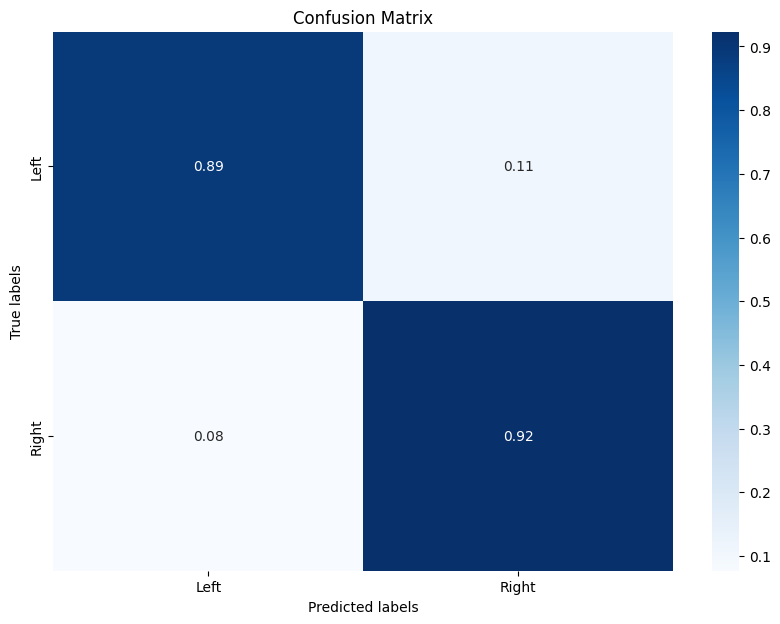

In [92]:
# =============================================================================
# 模型评估: 计算测试准确率 + 绘制混淆矩阵 (二分类)
# =============================================================================

# 定义两个运动想象类别名称
#   0: Left   -- 左手运动想象
#   1: Right  -- 右手运动想象
classes_list = ['Left', 'Right']

# 实例化评估器, 传入训练好的模型
eval_model = EvalModel(trained_eegnet_model)

# 第一步: 计算测试集准确率
test_accuracy = eval_model.test_model(test_dataset)

# 第二步: 绘制归一化混淆矩阵
eval_model.plot_confusion_matrix(test_dataset, classes_list)